<a href="https://colab.research.google.com/github/theMorana/HSE/blob/main/Deep_Learning/Homework_notebooks/RNN_homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Классификация текстов с помощью RNN (PyTorch)

- загрузка и визуализация данных;
- токенизация и словарь;
- RNN-классификатор;
- обучение, кривые, матрица ошибок;
- задания с плейсхолдерами для изменения гиперпараметров.

## 1. Окружение

In [86]:
!pip install -q datasets scikit-learn seaborn tqdm matplotlib

In [87]:
import re
import random
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torch.nn.utils.rnn import (
    pad_sequence,
    pack_padded_sequence
)

from datasets import load_dataset
from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm

In [88]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

print(f"Using device: {device}")

Using device: cuda


## 2. Загрузка данных

In [89]:
dataset = load_dataset("fancyzhx/ag_news")

print(dataset)
print("\nПример:", dataset['train'][0])

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})

Пример: {'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.", 'label': 2}


In [90]:
train_data = list(zip(
    dataset['train']['label'],
    dataset['train']['text']
))

test_data = list(zip(
    dataset['test']['label'],
    dataset['test']['text']
))

print(f"Обучающих примеров: {len(train_data)}")
print(f"Тестовых примеров: {len(test_data)}")

print(
    f"\nРаспределение меток: "
    f"{Counter(label for label, _ in train_data)}"
)

Обучающих примеров: 120000
Тестовых примеров: 7600

Распределение меток: Counter({2: 30000, 3: 30000, 1: 30000, 0: 30000})


## 3. Визуализация данных

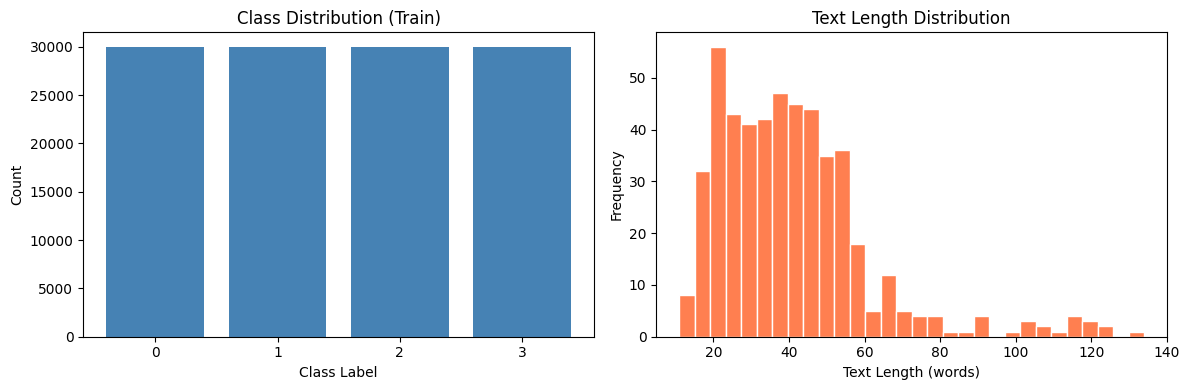

In [102]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

labels = [label for label, _ in train_data]
label_counts = Counter(labels)

axes[0].bar(
    label_counts.keys(),
    label_counts.values(),
    color='steelblue'
)

axes[0].set_xlabel('Class Label')
axes[0].set_ylabel('Count')
axes[0].set_title('Class Distribution (Train)')
axes[0].set_xticks([0, 1, 2, 3])

lengths = [
    len(text.split())
    for _, text in train_data[:500]
]

axes[1].hist(
    lengths,
    bins=30,
    color='coral',
    edgecolor='white'
)

axes[1].set_xlabel('Text Length (words)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Text Length Distribution')

plt.tight_layout()
plt.show()

In [103]:
print("\n=== Примеры ===")

for i in range(3):
    label, text = train_data[i]
    print(f"[Label {label}] {text[:150]}...")


=== Примеры ===
[Label 2] Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again....
[Label 2] Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed and ...
[Label 2] Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\about the economy and the outlook for earnings are expecte...


## 4. Токенизация и словарь

In [93]:
def tokenizer(text):
    """
    Простой токенизатор без torchtext.
    Приводит текст к нижнему регистру и отделяет пунктуацию.
    """
    return re.findall(
        r"\w+|[^\w\s]",
        text.lower()
    )


def yield_tokens(data):
    for _, text in data:
        yield tokenizer(text)

In [94]:
def build_vocab_from_iterator(iterator, min_freq=1):
    counter = Counter()

    for tokens in iterator:
        counter.update(tokens)

    # Индексы специальных токенов:
    # <pad> = 0
    # <unk> = 1
    vocab = {
        '<pad>': 0,
        '<unk>': 1,
    }

    frequent_tokens = [
        token
        for token, frequency in counter.items()
        if frequency >= min_freq
        and token not in ('<pad>', '<unk>')
    ]

    # Сначала частые слова, затем алфавитный порядок
    frequent_tokens.sort(
        key=lambda token: (-counter[token], token)
    )

    vocab.update({
        token: index
        for index, token in enumerate(
            frequent_tokens,
            start=2
        )
    })

    return vocab

In [95]:
# ============================================
# Задание 1: параметры построения словаря
# Попробуйте min_freq = 2 или 10. Как меняются размер словаря и качество модели?
# Почему редкие слова могут как помогать, так и мешать? - они могут как создавать шум, так и являться ключевыми (в случае терминов - названий технологий, лекарств и т.д.)
# ============================================
MIN_FREQ = 2
#MIN_FREQ = 5 --> Размер словаря = 27831
#MIN_FREQ = 10  --> Размер словаря = 19638

# Сначала строим словарь только из реальных токенов
vocab = build_vocab_from_iterator(
    yield_tokens(train_data),
    min_freq=MIN_FREQ
)

# Добавляем специальные токены вручную
# Порядок важен: <pad> должен быть первым (индекс 0), <unk> — вторым (индекс 1)

# Устанавливаем токен по умолчанию для неизвестных слов
PAD_IDX = vocab['<pad>']
UNK_IDX = vocab['<unk>']

print(f"Размер словаря: {len(vocab)}")
print(f"PAD_IDX = {PAD_IDX}, UNK_IDX = {UNK_IDX}")

Размер словаря: 44138
PAD_IDX = 0, UNK_IDX = 1


## 5. Предобработка и Dataset

In [31]:
# ============================================
# Задание 2: длина последовательности (обрезка)
# Попробуйте MAX_LEN = 128, 256, 512. Как меняются скорость обучения и точность?
# Почему у RNN может не быть выигрыша от очень длинных последовательностей?
# ============================================
MAX_LEN = 256  # <-- меняйте здесь

In [32]:
def text_pipeline(text):
    tokens = tokenizer(text)

    ids = [
        vocab.get(token, UNK_IDX)
        for token in tokens
    ]

    if len(ids) > MAX_LEN:
        ids = ids[:MAX_LEN]

    # На случай пустого текста
    if len(ids) == 0:
        ids = [UNK_IDX]

    return ids


def label_pipeline(label):
    return label

In [33]:
class AGNewsDataset(torch.utils.data.Dataset):
    def __init__(
        self,
        data,
        text_pipeline,
        label_pipeline
    ):
        self.data = data
        self.text_pipeline = text_pipeline
        self.label_pipeline = label_pipeline

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        label, text = self.data[idx]

        ids = self.text_pipeline(text)

        return (
            torch.tensor(ids, dtype=torch.long),
            torch.tensor(
                self.label_pipeline(label),
                dtype=torch.long
            )
        )

In [34]:
def collate_batch(batch):
    text_list, label_list = zip(*batch)

    lengths = torch.tensor(
        [len(text) for text in text_list],
        dtype=torch.long
    )

    padded = pad_sequence(
        text_list,
        batch_first=True,
        padding_value=PAD_IDX
    )

    labels = torch.stack(label_list)

    return padded, lengths, labels

In [35]:
train_dataset = AGNewsDataset(
    train_data,
    text_pipeline,
    label_pipeline
)

test_dataset = AGNewsDataset(
    test_data,
    text_pipeline,
    label_pipeline
)

## 6. DataLoader

In [36]:
# ============================================
# Задание 3: размер батча
# Попробуйте BATCH_SIZE = 32, 64, 128. Как это влияет на стабильность обучения и скорость?
# Документация: https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader
# ============================================
BATCH_SIZE = 64  # <-- меняйте здесь

In [37]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_batch,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_batch,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print(
    f"Количество батчей в обучении: "
    f"{len(train_loader)}"
)

Количество батчей в обучении: 1875


## 7. RNN-модель

In [38]:
class RNNClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        embed_dim,
        hidden_dim,
        num_classes,
        num_layers=1,
        dropout=0.2,
        bidirectional=False
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_dim,
            padding_idx=PAD_IDX
        )

        self.rnn = nn.RNN(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=bidirectional
        )

        rnn_output_dim = (
            hidden_dim * 2
            if bidirectional
            else hidden_dim
        )

        self.fc = nn.Linear(
            rnn_output_dim,
            num_classes
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, lengths):
        embedded = self.dropout(
            self.embedding(x)
        )

        packed = pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        _, hidden = self.rnn(packed)

        if self.rnn.bidirectional:
            last_hidden = torch.cat(
                [hidden[-2], hidden[-1]],
                dim=1
            )
        else:
            last_hidden = hidden[-1]

        output = self.fc(
            self.dropout(last_hidden)
        )

        return output

In [39]:
# ============================================
# Задание 4: гиперпараметры модели
# Попробуйте разные комбинации и посмотрите на точность на валидации:
#   EMBED_DIM: 64, 128, 256
#   HIDDEN_DIM: 64, 128, 256
#   NUM_LAYERS: 1, 2
#   BIDIRECTIONAL: True / False
# Как размер скрытого состояния связан с числом параметров и качеством?
# ============================================
EMBED_DIM = 128       # <-- меняйте здесь
HIDDEN_DIM = 128      # <-- меняйте здесь
NUM_LAYERS = 1        # <-- меняйте здесь
BIDIRECTIONAL = False # <-- меняйте здесь (True/False)
DROPOUT = 0.2

In [40]:
model = RNNClassifier(
    vocab_size=len(vocab),
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_classes=4,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    bidirectional=BIDIRECTIONAL
).to(device)

print(model)

print(
    f"Количество обучаемых параметров: "
    f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}"
)

RNNClassifier(
  (embedding): Embedding(44138, 128, padding_idx=0)
  (rnn): RNN(128, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=4, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)
Количество обучаемых параметров: 5,683,204


## 8. Обучение и проверка

In [41]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()

    total_loss = 0
    total_correct = 0
    total_samples = 0

    for texts, lengths, labels in tqdm(
        loader,
        desc="Training"
    ):
        texts = texts.to(device)
        lengths = lengths.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model(texts, lengths)
        loss = criterion(logits, labels)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        predictions = logits.argmax(dim=1)

        total_loss += (
            loss.item() * labels.size(0)
        )

        total_correct += (
            (predictions == labels)
            .sum()
            .item()
        )

        total_samples += labels.size(0)

    return (
        total_loss / total_samples,
        total_correct / total_samples
    )

In [42]:
def evaluate(model, loader, criterion):
    model.eval()

    total_loss = 0
    total_correct = 0
    total_samples = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for texts, lengths, labels in tqdm(
            loader,
            desc="Evaluating"
        ):
            texts = texts.to(device)
            lengths = lengths.to(device)
            labels = labels.to(device)

            logits = model(texts, lengths)
            loss = criterion(logits, labels)

            predictions = logits.argmax(dim=1)

            total_loss += (
                loss.item() * labels.size(0)
            )

            total_correct += (
                (predictions == labels)
                .sum()
                .item()
            )

            total_samples += labels.size(0)

            all_preds.extend(
                predictions.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

    return (
        total_loss / total_samples,
        total_correct / total_samples,
        all_preds,
        all_labels
    )

In [43]:
# ============================================
# Задание 5: параметры оптимизатора
# Попробуйте LEARNING_RATE = 1e-3, 5e-4, 1e-4.
# Как скорость обучения влияет на сходимость и стабильность?
# Документация: https://pytorch.org/docs/stable/optim.html#torch.optim.Adam
# ============================================
LEARNING_RATE = 1e-3  # <-- меняйте здесь
NUM_EPOCHS = 5        # <-- меняйте здесь

In [44]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_epoch(
        model,
        train_loader,
        optimizer,
        criterion
    )

    val_loss, val_acc, _, _ = evaluate(
        model,
        test_loader,
        criterion
    )

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(
        f"Epoch {epoch + 1}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

Evaluating: 100%|██████████| 119/119 [00:01<00:00, 103.98it/s]


Epoch 1/5 | Train Loss: 0.9041 | Train Acc: 0.6139 | Val Loss: 0.6205 | Val Acc: 0.7896


Evaluating: 100%|██████████| 119/119 [00:01<00:00, 71.59it/s]


Epoch 2/5 | Train Loss: 0.6120 | Train Acc: 0.7862 | Val Loss: 0.5206 | Val Acc: 0.8329


Evaluating: 100%|██████████| 119/119 [00:00<00:00, 120.65it/s]


Epoch 3/5 | Train Loss: 0.5071 | Train Acc: 0.8346 | Val Loss: 0.4956 | Val Acc: 0.8518


Evaluating: 100%|██████████| 119/119 [00:01<00:00, 114.22it/s]


Epoch 4/5 | Train Loss: 0.4482 | Train Acc: 0.8562 | Val Loss: 0.4459 | Val Acc: 0.8624


Evaluating: 100%|██████████| 119/119 [00:00<00:00, 119.69it/s]

Epoch 5/5 | Train Loss: 0.4063 | Train Acc: 0.8715 | Val Loss: 0.4333 | Val Acc: 0.8704


## 9. Кривые обучения

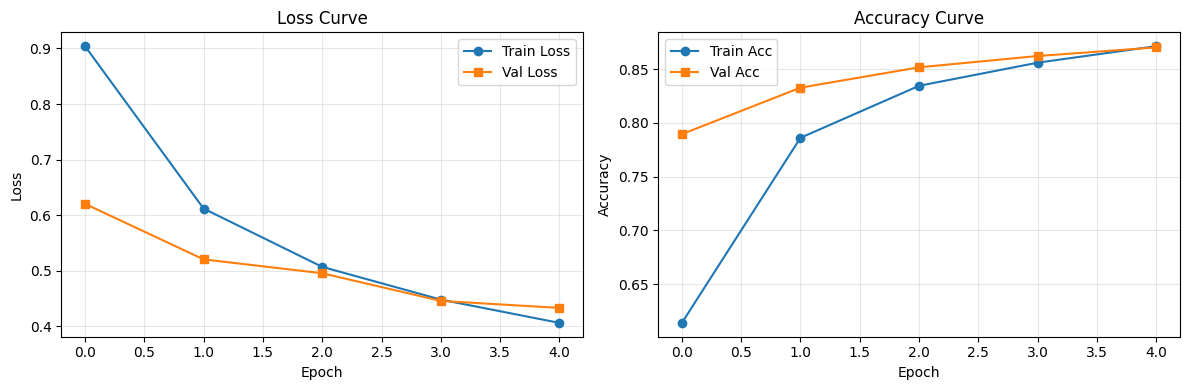

In [45]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4)
)

axes[0].plot(
    history['train_loss'],
    label='Train Loss',
    marker='o'
)

axes[0].plot(
    history['val_loss'],
    label='Val Loss',
    marker='s'
)

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Curve')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    history['train_acc'],
    label='Train Acc',
    marker='o'
)

axes[1].plot(
    history['val_acc'],
    label='Val Acc',
    marker='s'
)

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy Curve')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Матрица ошибок и classification report

In [46]:
val_loss, val_acc, all_preds, all_labels = evaluate(
    model,
    test_loader,
    criterion
)

print(f"Test loss: {val_loss:.4f}")
print(f"Test accuracy: {val_acc:.4f}")

Evaluating: 100%|██████████| 119/119 [00:00<00:00, 121.15it/s]

Test loss: 0.4333
Test accuracy: 0.8704


In [47]:
class_names = [
    'World',
    'Sports',
    'Business',
    'Sci/Tech'
]

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

       World       0.87      0.89      0.88      1900
      Sports       0.95      0.95      0.95      1900
    Business       0.90      0.74      0.81      1900
    Sci/Tech       0.78      0.90      0.83      1900

    accuracy                           0.87      7600
   macro avg       0.88      0.87      0.87      7600
weighted avg       0.88      0.87      0.87      7600



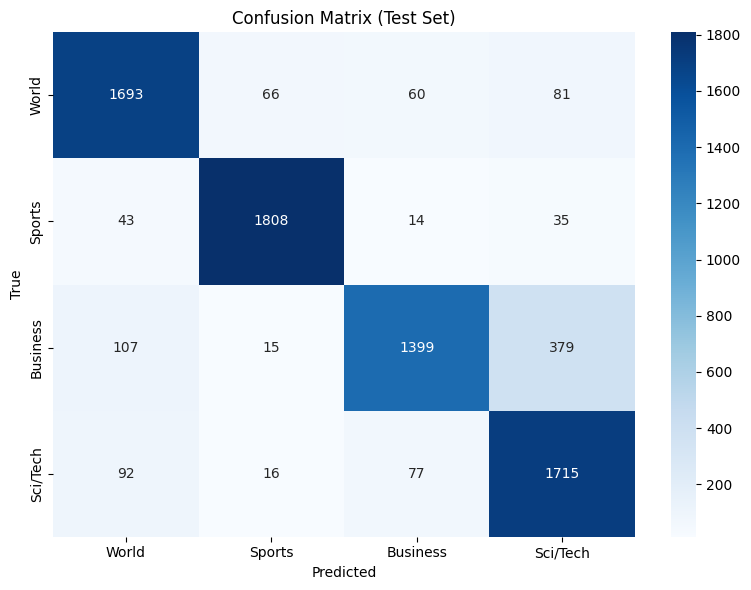

In [48]:
cm = confusion_matrix(
    all_labels,
    all_preds
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()

## 11. Контрольные вопросы для студентов

1. **Почему в этом ноутбуке используется `pack_padded_sequence`?**  
   Что произойдёт, если убрать `pack_padded_sequence` и просто подать `padded` тензор в RNN?

2. **Как `min_freq` влияет на размер словаря и на количество параметров embedding-слоя?**  
   Оцените, как меняется число обучаемых параметров при `MIN_FREQ = 2` и `MIN_FREQ = 10`.

3. **Что означает `lengths.cpu()` в вызове `pack_padded_sequence`?**  
   Почему длины должны быть на CPU, а не на GPU?

4. **Почему при `BIDIRECTIONAL = True` используется `torch.cat([hidden[-2], hidden[-1]], dim=1)`?**  
   Что хранится в `hidden[-2]` и `hidden[-1]`?

5. **Как размер `HIDDEN_DIM` связан с числом параметров RNN?**  
   Выведите формулу для числа параметров `nn.RNN` (без bias и с bias).

6. **Почему `clip_grad_norm_` особенно важен для RNN?**  
   С каким явлением он борется?

7. **Что произойдёт, если `MAX_LEN` сделать очень большим (например, 2048)?**  
   Как это повлияет на время обучения, память и качество?

8. **Почему `padding_idx=PAD_IDX` важен в `nn.Embedding`?**  
   Что произойдёт, если его не указывать?

9. **Как интерпретировать матрицу ошибок?**  
   Какие классы чаще всего путаются и почему?

10. **Почему accuracy может быть не лучшей метрикой для этой задачи?**  
    Посмотрите на `classification_report` и объясните, какие метрики здесь информативнее.

## 12. Домашнее задание

### Часть A. Эксперименты с гиперпараметрами

Проведите **минимум 5 экспериментов**, меняя по одному гиперпараметру за раз:

1. `MIN_FREQ`: 2, 5, 10
2. `MAX_LEN`: 128, 256, 512
3. `BATCH_SIZE`: 32, 64, 128
4. `EMBED_DIM` / `HIDDEN_DIM`: (64, 64), (128, 128), (256, 256)
5. `NUM_LAYERS`: 1, 2
6. `BIDIRECTIONAL`: True / False
7. `LEARNING_RATE`: 1e-3, 5e-4, 1e-4

Для каждого эксперимента зафиксируйте:
- размер словаря;
- число параметров модели;
- время одной эпохи;
- `val_loss` и `val_acc` после 3–5 эпох.

Сведите результаты в таблицу и постройте графики зависимости `val_acc` от каждого гиперпараметра.

### Часть B. Анализ ошибок

1. Найдите **10 примеров**, на которых модель ошибается.
2. Для каждого примера укажите: истинный класс, предсказанный класс, текст (можно первые 200 символов).
3. Предложите **гипотезы**, почему модель ошибается (короткий текст, смешанная тематика, редкие слова и т.д.).
4. Предложите **2–3 идеи**, как улучшить модель именно на этих примерах.

### Часть C. Улучшение архитектуры

Замените `nn.RNN` на одну из архитектур:
- `nn.LSTM`
- `nn.GRU`
- двунаправленный LSTM/GRU

Сравните с базовой RNN по тем же метрикам. Объясните, почему LSTM/GRU часто работают лучше на длинных последовательностях.

### Часть D. Мини-исследование

Проверьте гипотезу: **«чем длиннее текст, тем лучше модель его классифицирует»**.

1. Разбейте тестовые примеры на группы по длине (например, 0–50, 51–100, 101–200, 200+ слов).
2. Посчитайте accuracy для каждой группы.
3. Постройте график зависимости accuracy от длины.
4. Сформулируйте вывод: подтверждается ли гипотеза?

### Формат сдачи

- Ноутбук `.ipynb` со всеми выполненными ячейками.
- Краткий отчёт (markdown внутри ноутбука): таблица экспериментов, графики, анализ ошибок, выводы.
- Ссылка на GitHub / Colab или сам файл.

#Homework Task №1

I decided to make a function which would run all the experiments in a cicle. So I needed to rewrite previous code for basic functions.

In [124]:
def make_vocab_from_iterator(iterator, min_freq=1):
    counter = Counter()
    for tokens in iterator:
        counter.update(tokens)

    vocab = {'<pad>': 0, '<unk>': 1}
    frequent_tokens = [
        t for t, f in counter.items()
        if f >= min_freq and t not in ('<pad>', '<unk>')
    ]
    frequent_tokens.sort(key=lambda t: (-counter[t], t))
    vocab.update({t: i for i, t in enumerate(frequent_tokens, start=2)})
    return vocab


def build_vocab(train_data, min_freq):
    return make_vocab_from_iterator(
        yield_tokens(train_data),
        min_freq=min_freq
    )


def make_text_pipeline(vocab, max_len):
    """Return function text_pipeline for paticular dictionary & max_len."""
    def text_pipeline(text):
        tokens = tokenizer(text)
        ids = [vocab.get(token, vocab['<unk>']) for token in tokens]

        if len(ids) > max_len:
            ids = ids[:max_len]

        if len(ids) == 0:
            ids = [vocab['<unk>']]

        return ids

    return text_pipeline


def make_collate_fn(pad_idx):
    """return collate_fn with necessary padding_value."""
    def collate_batch(batch):
        text_list, label_list = zip(*batch)

        lengths = torch.tensor(
            [len(text) for text in text_list],
            dtype=torch.long
        )

        padded = pad_sequence(
            text_list,
            batch_first=True,
            padding_value=pad_idx
        )

        labels = torch.stack(label_list)

        return padded, lengths, labels

    return collate_batch


def make_dataloaders(train_data, test_data, vocab, max_len, batch_size):
    """Create train_loader & test_loader for set parameters"""
    text_pipeline = make_text_pipeline(vocab, max_len)
    collate_fn = make_collate_fn(vocab['<pad>'])

    train_dataset = AGNewsDataset(train_data, text_pipeline, label_pipeline)
    test_dataset  = AGNewsDataset(test_data,  text_pipeline, label_pipeline)

    pin = torch.cuda.is_available()

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=collate_fn,
        num_workers=2,
        pin_memory=pin
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_fn,
        num_workers=2,
        pin_memory=pin
    )

    return train_loader, test_loader

class RNNClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        embed_dim,
        hidden_dim,
        num_classes,
        pad_idx,
        num_layers=1,
        dropout=0.2,
        bidirectional=False
    ):
        super().__init__()

        self.pad_idx = pad_idx

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_dim,
            padding_idx=pad_idx
        )

        self.rnn = nn.RNN(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=bidirectional
        )

        rnn_output_dim = hidden_dim * 2 if bidirectional else hidden_dim

        self.fc = nn.Linear(rnn_output_dim, num_classes)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, lengths):
        embedded = self.dropout(self.embedding(x))

        packed = pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        _, hidden = self.rnn(packed)

        if self.rnn.bidirectional:
            last_hidden = torch.cat([hidden[-2], hidden[-1]], dim=1)
        else:
            last_hidden = hidden[-1]

        return self.fc(self.dropout(last_hidden))

In [126]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()

    total_loss = 0
    total_correct = 0
    total_samples = 0

    for texts, lengths, labels in loader:
        texts   = texts.to(device)
        lengths = lengths.to(device)
        labels  = labels.to(device)

        optimizer.zero_grad()
        logits = model(texts, lengths)
        loss = criterion(logits, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        preds = logits.argmax(dim=1)

        total_loss += loss.item() * labels.size(0)
        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

    return total_loss / total_samples, total_correct / total_samples


def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0
    total_correct = 0
    total_samples = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for texts, lengths, labels in loader:
            texts   = texts.to(device)
            lengths = lengths.to(device)
            labels  = labels.to(device)

            logits = model(texts, lengths)
            loss = criterion(logits, labels)
            preds = logits.argmax(dim=1)

            total_loss += loss.item() * labels.size(0)
            total_correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return (
        total_loss / total_samples,
        total_correct / total_samples,
        all_preds,
        all_labels
    )

In [133]:
def run_experiment(
    name,
    train_data,
    test_data,
    min_freq=5,
    max_len=256,
    batch_size=64,
    embed_dim=128,
    hidden_dim=128,
    num_layers=1,
    bidirectional=False,
    dropout=0.2,
    learning_rate=1e-3,
    num_epochs=5,
    num_classes=4,
    seed=42,
    verbose=True
):
    """Run one experiment and retutn dictionary with results"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # dictionary
    vocab = build_vocab(train_data, min_freq=min_freq)

    # loader
    train_loader, test_loader = make_dataloaders(
        train_data, test_data, vocab,
        max_len=max_len, batch_size=batch_size
    )

    # model
    model = RNNClassifier(
        vocab_size=len(vocab),
        embed_dim=embed_dim,
        hidden_dim=hidden_dim,
        num_classes=num_classes,
        pad_idx=vocab['<pad>'],
        num_layers=num_layers,
        dropout=dropout,
        bidirectional=bidirectional
    ).to(device)

    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # learning
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    epoch_times = []

    for epoch in range(num_epochs):
        t0 = time.time()
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        epoch_time = time.time() - t0

        va_loss, va_acc, _, _ = evaluate(model, test_loader, criterion, device)

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(va_loss)
        history['val_acc'].append(va_acc)
        epoch_times.append(epoch_time)

        if verbose:
            print(
                f"[{name}] Epoch {epoch+1}/{num_epochs} | "
                f"Train Loss: {tr_loss:.4f} | Train Acc: {tr_acc:.4f} | "
                f"Val Loss: {va_loss:.4f} | Val Acc: {va_acc:.4f} | "
                f"Time: {epoch_time:.1f}s"
            )

    result = {
        'name': name,
        'min_freq': min_freq,
        'max_len': max_len,
        'batch_size': batch_size,
        'embed_dim': embed_dim,
        'hidden_dim': hidden_dim,
        'num_layers': num_layers,
        'bidirectional': bidirectional,
        'learning_rate': learning_rate,
        'vocab_size': len(vocab),
        'n_params': n_params,
        'avg_epoch_time': float(np.mean(epoch_times)),
        'final_val_loss': history['val_loss'][-1],
        'final_val_acc': history['val_acc'][-1],
        'history': history,
    }
    return result

In [134]:
EXPERIMENTS = [
    dict(
        name="E1_baseline",
        min_freq=5, max_len=256, batch_size=64,
        embed_dim=128, hidden_dim=128,
        num_layers=1, bidirectional=False,
        learning_rate=1e-3
    ),
    dict(
        name="E2_min_freq=2",
        min_freq=2, max_len=256, batch_size=64,
        embed_dim=128, hidden_dim=128,
        num_layers=1, bidirectional=False,
        learning_rate=1e-3
    ),
    dict(
        name="E3_max_len=128",
        min_freq=5, max_len=128, batch_size=64,
        embed_dim=128, hidden_dim=128,
        num_layers=1, bidirectional=False,
        learning_rate=1e-3
    ),
    dict(
        name="E4_batch_size=128",
        min_freq=5, max_len=256, batch_size=128,
        embed_dim=128, hidden_dim=128,
        num_layers=1, bidirectional=False,
        learning_rate=1e-3
    ),
    dict(
        name="E5_bidirectional_2layers",
        min_freq=5, max_len=256, batch_size=64,
        embed_dim=128, hidden_dim=128,
        num_layers=2, bidirectional=True,
        learning_rate=1e-3
    ),
]

NUM_EPOCHS = 5

results = []
for exp in EXPERIMENTS:
    res = run_experiment(
        **exp,
        train_data=train_data,
        test_data=test_data,
        num_epochs=NUM_EPOCHS,
        verbose=True
    )
    results.append(res)
    print("-" * 80)

[E1_baseline] Epoch 1/5 | Train Loss: 0.8881 | Train Acc: 0.6220 | Val Loss: 0.6758 | Val Acc: 0.7532 | Time: 29.3s
[E1_baseline] Epoch 2/5 | Train Loss: 0.5923 | Train Acc: 0.7969 | Val Loss: 0.5181 | Val Acc: 0.8304 | Time: 26.6s
[E1_baseline] Epoch 3/5 | Train Loss: 0.5061 | Train Acc: 0.8357 | Val Loss: 0.4894 | Val Acc: 0.8441 | Time: 26.4s
[E1_baseline] Epoch 4/5 | Train Loss: 0.4484 | Train Acc: 0.8595 | Val Loss: 0.4361 | Val Acc: 0.8667 | Time: 26.7s
[E1_baseline] Epoch 5/5 | Train Loss: 0.4016 | Train Acc: 0.8743 | Val Loss: 0.4282 | Val Acc: 0.8697 | Time: 26.6s
--------------------------------------------------------------------------------
[E2_min_freq=2] Epoch 1/5 | Train Loss: 0.9041 | Train Acc: 0.6139 | Val Loss: 0.6205 | Val Acc: 0.7896 | Time: 28.6s
[E2_min_freq=2] Epoch 2/5 | Train Loss: 0.6120 | Train Acc: 0.7862 | Val Loss: 0.5206 | Val Acc: 0.8329 | Time: 27.7s
[E2_min_freq=2] Epoch 3/5 | Train Loss: 0.5071 | Train Acc: 0.8346 | Val Loss: 0.4956 | Val Acc: 0.8518

In [135]:
df = pd.DataFrame([{
    'experiment':        r['name'],
    'min_freq':          r['min_freq'],
    'max_len':           r['max_len'],
    'batch_size':        r['batch_size'],
    'embed/hidden':      f"{r['embed_dim']}/{r['hidden_dim']}",
    'num_layers':        r['num_layers'],
    'bidirectional':     r['bidirectional'],
    'lr':                r['learning_rate'],
    'vocab_size':        r['vocab_size'],
    'n_params':          r['n_params'],
    'avg_epoch_time_s':  round(r['avg_epoch_time'], 1),
    'final_val_loss':    round(r['final_val_loss'], 4),
    'final_val_acc':     round(r['final_val_acc'], 4),
} for r in results])

df

,experiment,min_freq,max_len,batch_size,embed/hidden,num_layers,bidirectional,lr,vocab_size,n_params,avg_epoch_time_s,final_val_loss,final_val_acc
0,E1_baseline,5,256,64,128/128,1,False,0.001,27831,3595908,27.1,0.4282,0.8697
1,E2_min_freq=2,2,256,64,128/128,1,False,0.001,44138,5683204,28.0,0.4333,0.8704
2,E3_max_len=128,5,128,64,128/128,1,False,0.001,27831,3595908,25.7,0.4194,0.8739
3,E4_batch_size=128,5,256,128,128/128,1,False,0.001,27831,3595908,17.4,0.4396,0.8651
4,E5_bidirectional_2layers,5,256,64,128/128,2,True,0.001,27831,3728260,49.3,0.2967,0.8997


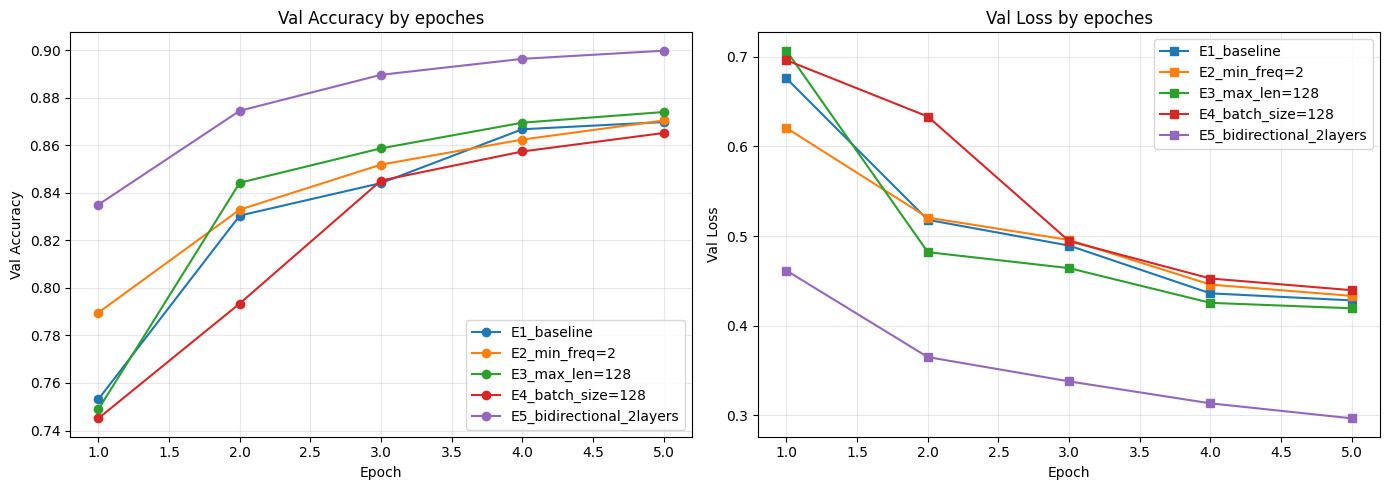

In [136]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for r in results:
    axes[0].plot(
        range(1, len(r['history']['val_acc']) + 1),
        r['history']['val_acc'],
        marker='o', label=r['name']
    )
    axes[1].plot(
        range(1, len(r['history']['val_loss']) + 1),
        r['history']['val_loss'],
        marker='s', label=r['name']
    )

axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Val Accuracy')
axes[0].set_title('Val Accuracy by epoches'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val Loss')
axes[1].set_title('Val Loss by epoches'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

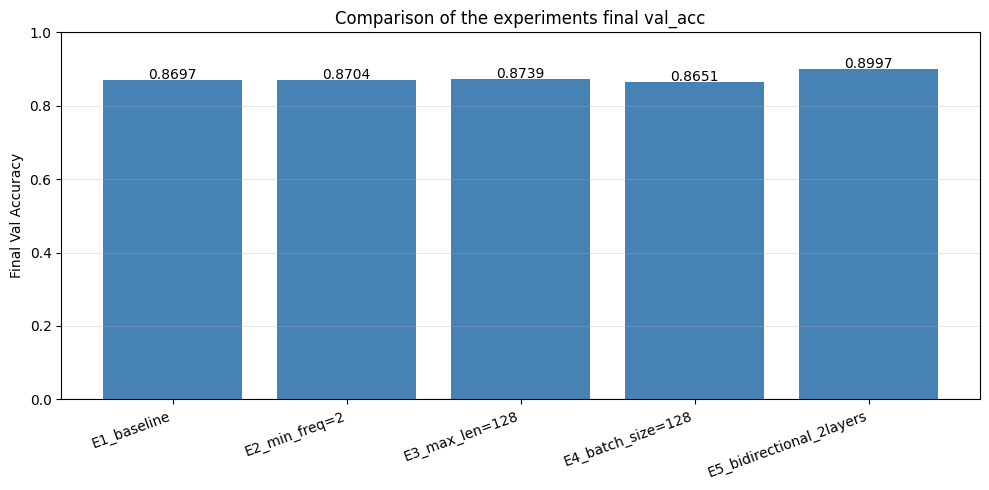

In [137]:
plt.figure(figsize=(10, 5))
bars = plt.bar(df['experiment'], df['final_val_acc'], color='steelblue')

for b, v in zip(bars, df['final_val_acc']):
    plt.text(b.get_x() + b.get_width()/2, v + 0.002,
             f"{v:.4f}", ha='center', fontsize=10)

plt.ylim(0, 1.0)
plt.ylabel('Final Val Accuracy')
plt.title('Comparison of the experiments final val_acc')
plt.xticks(rotation=20, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

#Homework Task #2

In [138]:
class_names = ['World', 'Sports', 'Business', 'Sci/Tech']
# 0 → World, 1 → Sports, 2 → Business, 3 → Sci/Tech

from collections import Counter
print("Labels in test_data:", Counter(label for label, _ in test_data))

val_loss, val_acc, all_preds, all_labels = evaluate(
    model, test_loader, criterion, device
)
print(f"Test accuracy: {val_acc:.4f}")


errors = []
for i, (true_lbl, pred_lbl) in enumerate(zip(all_labels, all_preds)):
    if true_lbl != pred_lbl:
        _, text = test_data[i]
        errors.append({
            'true': int(true_lbl),
            'pred': int(pred_lbl),
            'text': text,
        })

print(f"Total errors: {len(errors)} из {len(test_data)}")

#first 10
for n, e in enumerate(errors[:10], start=1):
    short = e['text'][:200].replace('\n', ' ')
    print(f"\n#{n}")
    print(f"  True class:      [{e['true']}] {class_names[e['true']]}")
    print(f"  Predicted class: [{e['pred']}] {class_names[e['pred']]}")
    print(f"  Text: {short}...")

Labels in test_data: Counter({2: 1900, 3: 1900, 1: 1900, 0: 1900})
Test accuracy: 0.8704
Total errors: 985 из 7600

#1
  True class:      [3] Sci/Tech
  Predicted class: [1] Sports
  Text: Prediction Unit Helps Forecast Wildfires (AP) AP - It's barely dawn when Mike Fitzpatrick starts his shift with a blur of colorful maps, figures and endless charts, but already he knows what the day w...

#2
  True class:      [3] Sci/Tech
  Predicted class: [0] World
  Text: Rocking the Cradle of Life When did life begin? One evidential clue stems from the fossil records in Western Australia, although whether these layered sediments are biological or chemical has spawned ...

#3
  True class:      [3] Sci/Tech
  Predicted class: [2] Business
  Text: Some People Not Eligible to Get in on Google IPO Google has billed its IPO as a way for everyday people to get in on the process, denying Wall Street the usual stranglehold it's had on IPOs. Public bi...

#4
  True class:      [3] Sci/Tech
  Predicted cl

**Typical errors**

1. **Named entities outweigh the theme.** The names of companies (Intel, Google, Charles Schwab), countries (India, Australia, Western), and cities (SAN FRANCISCO) dominate the solution, although the topic itself may be different.

2. **Borderline topics.** Business <--> Sci/Tech (IPO, stocks, products), World <--> Sports (Olympics, participating countries) are by definition blurred boundaries.

3. **The absence of explicit "thematic" markers.** In text #1, there are no words computer, software, research — only a description of the process, which in itself is neutral.


**Ideas:**
1. Attention/mean pooling for all RNN steps instead of hidden[-1] — the model focuses on characteristic words rather than relying on a single keyword.

2. Class-weighted CrossEntropyLoss — increased weight for classes where the model makes mistakes more often (Sci/Tech, World), which enhances the gradient precisely on boundary examples.

3. Augmentation of short/ambiguous texts (synonymous substitutions, low—probability dropout of key tokens) - forces the model not to memorize the "one word = one class" rule, which directly combats errors #3 and #9.

#Homework Task #3

In [139]:
class LSTMClassifierV2(nn.Module):
    def __init__(
        self,
        vocab_size,
        embed_dim,
        hidden_dim,
        num_classes,
        pad_idx,
        num_layers=1,
        dropout=0.2,
        bidirectional=False,
        rnn_type='LSTM'          # 'RNN' | 'LSTM' | 'GRU'
    ):
        super().__init__()

        self.rnn_type = rnn_type
        self.bidirectional = bidirectional

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_dim,
            padding_idx=pad_idx
        )

        rnn_cls = {'LSTM': nn.LSTM}[rnn_type]

        self.rnn = rnn_cls(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=bidirectional
        )

        rnn_output_dim = hidden_dim * 2 if bidirectional else hidden_dim

        self.fc = nn.Linear(rnn_output_dim, num_classes)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, lengths):
        embedded = self.dropout(self.embedding(x))

        packed = pack_padded_sequence(
            embedded, lengths.cpu(),
            batch_first=True, enforce_sorted=False
        )

        output, hidden = self.rnn(packed)

        if self.rnn_type == 'LSTM':
            hidden = hidden[0]

        if self.bidirectional:
            last_hidden = torch.cat([hidden[-2], hidden[-1]], dim=1)
        else:
            last_hidden = hidden[-1]

        return self.fc(self.dropout(last_hidden))

In [140]:
def run_experiment(
    name,
    train_data, test_data,
    min_freq=5, max_len=128, batch_size=64,
    embed_dim=128, hidden_dim=128,
    num_layers=2, bidirectional=True,
    dropout=0.2, learning_rate=1e-3,
    num_epochs=5, num_classes=4,
    rnn_type='RNN',
    seed=42, verbose=True
):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    vocab = build_vocab(train_data, min_freq=min_freq)
    train_loader, test_loader = make_dataloaders(
        train_data, test_data, vocab,
        max_len=max_len, batch_size=batch_size
    )

    model = LSTMClassifierV2(
        vocab_size=len(vocab),
        embed_dim=embed_dim, hidden_dim=hidden_dim,
        num_classes=num_classes, pad_idx=vocab['<pad>'],
        num_layers=num_layers, dropout=dropout,
        bidirectional=bidirectional, rnn_type=rnn_type
    ).to(device)

    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    epoch_times = []

    for epoch in range(num_epochs):
        t0 = time.time()
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        ep_time = time.time() - t0
        va_loss, va_acc, _, _ = evaluate(model, test_loader, criterion, device)

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(va_loss)
        history['val_acc'].append(va_acc)
        epoch_times.append(ep_time)

        if verbose:
            print(f"[{name}] Ep {epoch+1}/{num_epochs} | "
                  f"TrLoss {tr_loss:.4f} TrAcc {tr_acc:.4f} | "
                  f"VaLoss {va_loss:.4f} VaAcc {va_acc:.4f} | {ep_time:.1f}s")

    return {
        'name': name, 'rnn_type': rnn_type,
        'num_layers': num_layers, 'bidirectional': bidirectional,
        'vocab_size': len(vocab), 'n_params': n_params,
        'avg_epoch_time': float(np.mean(epoch_times)),
        'final_val_loss': history['val_loss'][-1],
        'final_val_acc': history['val_acc'][-1],
        'history': history,
    }

In [141]:
EXPERIMENTS = [
    dict(name="C3_biLSTM_2L", rnn_type='LSTM', num_layers=2, bidirectional=True),
]

results = []
for exp in EXPERIMENTS:
    res = run_experiment(
        **exp,
        train_data=train_data, test_data=test_data,
        min_freq=5, max_len=128, batch_size=64,
        embed_dim=128, hidden_dim=128,
        dropout=0.2, learning_rate=1e-3,
        num_epochs=5, verbose=True
    )
    results.append(res)
    print("-" * 80)

[C3_biLSTM_2L] Ep 1/5 | TrLoss 0.4797 TrAcc 0.8224 | VaLoss 0.2960 VaAcc 0.8987 | 54.0s
[C3_biLSTM_2L] Ep 2/5 | TrLoss 0.2637 TrAcc 0.9092 | VaLoss 0.2488 VaAcc 0.9149 | 53.3s
[C3_biLSTM_2L] Ep 3/5 | TrLoss 0.2063 TrAcc 0.9284 | VaLoss 0.2358 VaAcc 0.9221 | 52.6s
[C3_biLSTM_2L] Ep 4/5 | TrLoss 0.1708 TrAcc 0.9402 | VaLoss 0.2290 VaAcc 0.9247 | 52.3s
[C3_biLSTM_2L] Ep 5/5 | TrLoss 0.1419 TrAcc 0.9499 | VaLoss 0.2375 VaAcc 0.9257 | 52.7s
--------------------------------------------------------------------------------


In [142]:
df_2 = pd.DataFrame([{
    'experiment':       r['name'],
    'rnn_type':         r['rnn_type'],
    'num_layers':       r['num_layers'],
    'bidirectional':    r['bidirectional'],
    'vocab_size':       r['vocab_size'],
    'n_params':         r['n_params'],
    'avg_epoch_time_s': round(r['avg_epoch_time'], 1),
    'final_val_loss':   round(r['final_val_loss'], 4),
    'final_val_acc':    round(r['final_val_acc'], 4),
} for r in results])

df_2

,experiment,rnn_type,num_layers,bidirectional,vocab_size,n_params,avg_epoch_time_s,final_val_loss,final_val_acc
0,C3_biLSTM_2L,LSTM,2,True,27831,4222852,53.0,0.2375,0.9257


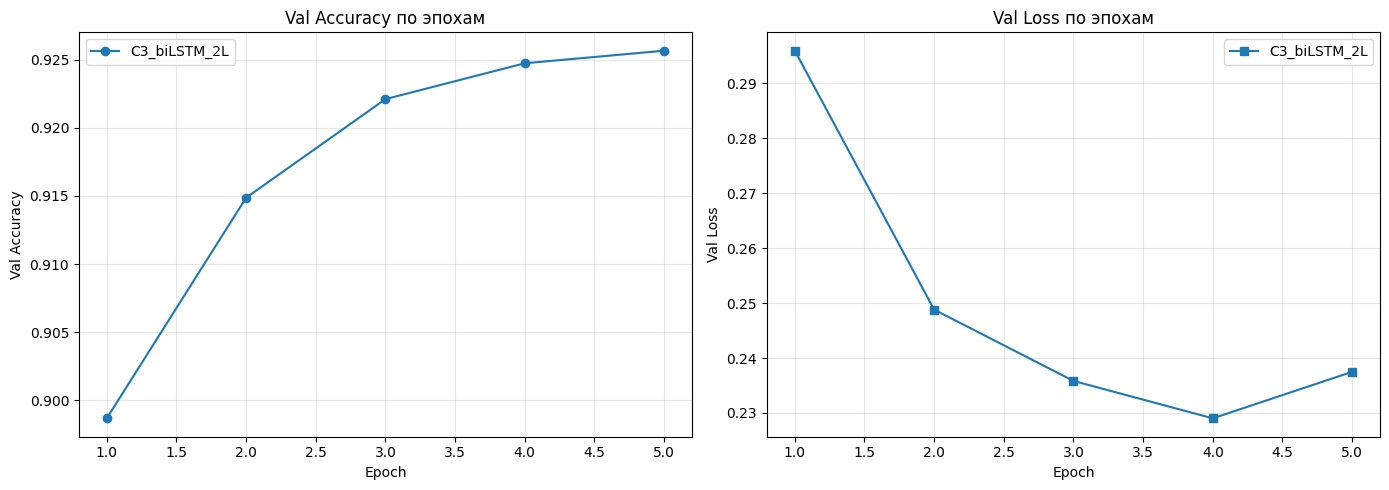

In [143]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for r in results:
    epochs = range(1, len(r['history']['val_acc']) + 1)
    axes[0].plot(epochs, r['history']['val_acc'], marker='o', label=r['name'])
    axes[1].plot(epochs, r['history']['val_loss'], marker='s', label=r['name'])

axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Val Accuracy')
axes[0].set_title('Val Accuracy по эпохам'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val Loss')
axes[1].set_title('Val Loss по эпохам'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

The result: the accuracy increased (0.8997 → 0.9257), the val loss dropped by 20%, the number of parameters increased, and the time practically did not change.

LSTM and GRU work better than RNN because their memory is designed so that the gradient can spread over hundreds of steps without exponential decay. They are trained to selectively memorize and forget, and this allows the model to use information throughout the entire length of the text, not just at the end.

#Homework Task #4

In [119]:
val_loss, val_acc, all_preds, all_labels = evaluate(
    model, test_loader, criterion, device
)
print(f"Test accuracy: {val_acc:.4f}")

#lengths
word_lengths = np.array([len(text.split()) for _, text in test_data])
correct = (np.array(all_preds) == np.array(all_labels)).astype(int)

# groups by length
bins   = [0, 50, 100, 200, 10_000]
labels = ['0–50', '51–100', '101–200', '200+']

group_ids = np.digitize(word_lengths, bins) - 1

rows = []
for gid, gname in enumerate(labels):
    mask = group_ids == gid
    n = int(mask.sum())
    acc = float(correct[mask].mean()) if n > 0 else float('nan')
    rows.append({'group': gname, 'n': n, 'accuracy': acc})

length_df = pd.DataFrame(rows)
print(length_df)

Test accuracy: 0.8704
     group     n  accuracy
0     0–50  6996  0.870640
1   51–100   586  0.868601
2  101–200    18  0.833333
3     200+     0       NaN


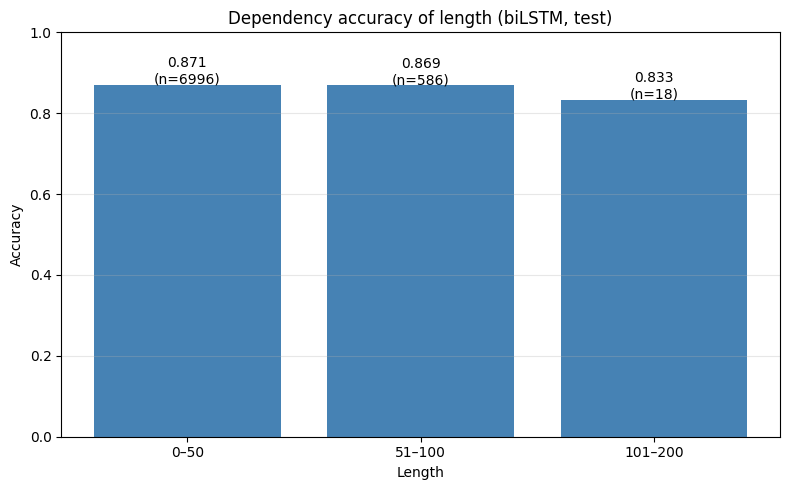

In [121]:
plt.figure(figsize=(8, 5))

bars = plt.bar(length_df['group'], length_df['accuracy'], color='steelblue')

for b, acc, n in zip(bars, length_df['accuracy'], length_df['n']):
    plt.text(b.get_x() + b.get_width()/2, acc + 0.003,
             f"{acc:.3f}\n(n={n})", ha='center', fontsize=10)

plt.ylim(0, 1.0)
plt.xlabel('Length')
plt.ylabel('Accuracy')
plt.title('Dependency accuracy of length (biLSTM, test)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [123]:
#accuracy for each group
for gid, gname in enumerate(labels):
    mask = group_ids == gid
    if mask.sum() == 0:
        continue
    print(f"{gname:>8}  n={mask.sum():>5}  acc={correct[mask].mean():.3f}")

    0–50  n= 6996  acc=0.871
  51–100  n=  586  acc=0.869
 101–200  n=   18  acc=0.833


The conclusion "the longer the text, the better the model identifies it" is erroneous, since we see the opposite dynamics in the graphs and accuracy indicators - short texts are better defined.